# **Assignment 10**

Take a small model and a real loop, and make it tell you the truth about itself.


**1. Print every tensor shape in the step**, and write one line saying what each dimension means.

**2. Verify one gradient by hand.** Nudge a weight, measure how the loss changed, and compare against what backward() reported. They should agree to several decimals, and if they do not, you have found something worth understanding.

**3. Break gradient accumulation on purpose.** Use the average of the averages with micro-batches of different lengths, and plot both curves together so you see the gap rather than take my word for it.

**4. Log the grad norm at every step**, then find one step where it moved before the loss did.

**5. Compute your own MFU**, report it honestly, and say what you believe is costing you the distance to 40%.

**6. Take the number 0.1** and write out by hand what it looks like in fp32, bf16 and fp8 E4M3, showing the bits. Then say which one you would train in, and why.


# **Install Dependencies**

In [1]:
!pip install tiktoken

In [2]:
! git clone https://github.com/karpathy/build-nanogpt.git nanogpt

Cloning into 'nanogpt'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 132 (delta 69), reused 56 (delta 56), pack-reused 48 (from 1)
Receiving objects: 100% (132/132), 461.03 KiB | 3.16 MiB/s, done.
Resolving deltas: 100% (69/69), done.


# **Imports**

In [3]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import tiktoken
from dataclasses import dataclass
import numpy as np
import random

import os
import psutil
import gc
import time


In [4]:
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)


In [5]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")

using device: cuda


# **Model Definition**

The model is built from Andrej Karpathy's Nanogpt: https://github.com/karpathy/build-nanogpt.git  




In [6]:
@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension
    tie_weights: bool = True # Make weight tying as optional


In [7]:
class CausalSelfAttention(nn.Module):

    def __init__(self, config, print_shapes=False):
        super().__init__()

        # embedding dimension must be evenly divisible among the attention heads
        assert config.n_embd % config.n_head == 0
        self.print_shapes = print_shapes

        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)

        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1

        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def debug_shape(self, name, x, meaning):
        if self.print_shapes:
            if x is not None and type(x) is not str:
                print(f"{name:40s} {str(tuple(x.shape)):20s} # {meaning}")
            else:
                val = x if type(x) == str else ""
                print(f"{name:40s} {val:20s} {meaning}")


    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)

        self.debug_shape("\nCausalSelfAttention:", None, "")
        self.debug_shape(" q projected", q, "(B, T, C)")
        self.debug_shape(" k projected", k, "(B, T, C)")
        self.debug_shape(" v projected", v, "(B, T, C)\n")

        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        self.debug_shape(" q after head split", q, "(B, H, T, D)")
        self.debug_shape(" k after head split", k, "(B, H, T, D)")
        self.debug_shape(" v after head split", v, "(B, H, T, D)")

        self.debug_shape("\nscaled_dot_product_attention:", None, "")
        self.debug_shape(" attention scores*", "(8, 4, 128, 128)*", "# (B, H, T_query, T_key)")
        self.debug_shape(" attention weights*", "(8, 4, 128, 128)*", "# (B, H, T_query, T_key)")

        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention
        self.debug_shape(" output", y, "(B, H, T, D)")
        self.debug_shape(" * implicit/intermediate shapes; not returned by F.scaled_dot_product_attention()", None, "\n")

        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        self.debug_shape("output attn (merged heads)", y, "(B, T, C)")

        # output projection
        y = self.c_proj(y)
        self.debug_shape("output projection", y, "(B, T, C)\n")


        return y


In [8]:
class MLP(nn.Module):

    def __init__(self, config, print_shapes=False):
        super().__init__()
        self.print_shapes = print_shapes
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu    = nn.GELU(approximate='tanh')
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def debug_shape(self, name, x, meaning):
        if self.print_shapes:
            if x is not None and type(x) is not str:
                print(f"{name:40s} {str(tuple(x.shape)):20s} # {meaning}")
            else:
                val = x if type(x) == str else ""
                print(f"{name:40s} {val:20s} {meaning}")

    def forward(self, x):
        self.debug_shape("MLP:", None, "")
        self.debug_shape( "input", x, "(B, T, C)")
        x = self.c_fc(x)
        self.debug_shape( "hidden", x, "(B, T, 4C)")
        x = self.gelu(x)
        x = self.c_proj(x)
        self.debug_shape( "output", x, "(B, T, C)")
        return x


In [9]:
class Block(nn.Module):

    def __init__(self, config, print_shapes=False):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config, print_shapes)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config, print_shapes)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


In [10]:
class GPT(nn.Module):

    def __init__(self, config, print_shapes=False):
        super().__init__()
        self.config = config
        self.print_shapes = print_shapes

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([
                Block(config, print_shapes=self.print_shapes)
                  for i in range(config.n_layer)
            ]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme
        if config.tie_weights:
            self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def debug_shape(self, name, x, meaning):
        if self.print_shapes:
            print(f"{name:40s} {str(tuple(x.shape)):20s} # {meaning}")

    def enable_shape_printing(self, block_idx=0):
        self.print_shapes = True
        for i, block in enumerate(self.transformer.h):
            block.print_shapes = False
            block.attn.print_shapes = (i == block_idx)
            block.mlp.print_shapes = (i == block_idx)

    def disable_shape_printing(self):
        self.print_shapes = False

        # for block in self.transformer.h:
        #     block.attn.print_shapes = False

        for module in self.modules():
            if hasattr(module, "print_shapes"):
                module.print_shapes = False


    def forward(self, idx, targets=None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
        self.debug_shape( "tokens", idx, "(B, T)")

        # forward the token and posisition embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        x = tok_emb + pos_emb
        self.debug_shape("embeddings (tok+pos)", x, "(B, T, C)")

        # forward the blocks of the transformer
        for block in self.transformer.h:
            x = block(x)
        self.debug_shape("\ntransformer output", x, "(B, T, C)")

        # forward the final layernorm and the classifier
        x = self.transformer.ln_f(x)

        logits = self.lm_head(x) # (B, T, vocab_size)
        self.debug_shape("LM head logits", logits, "(B, T, V)")

        return logits


# **Model Instantiation**

## Model Configs

In [11]:
B = 8   # Batch Size
T = 128 # Seq Length

vocab_size = 50257
n_layer    = 4
n_head     = 4
n_embd     = 256

## Create a model, tokenizer and optimizer

In [12]:
# Create a small model
config = GPTConfig(
    block_size=T,
    vocab_size=vocab_size,
    n_layer=n_layer,
    n_head=n_head,
    n_embd=n_embd
)
model = GPT(config)
model.to(device)

# Tokenizer
enc = tiktoken.get_encoding("gpt2")

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4
)

### **Create training batches from input file**

In [13]:
# Read data
with open("nanogpt/input.txt", "r") as f:
    text = f.read()

data = torch.tensor(
    enc.encode(text),
    dtype=torch.long
)

def get_batch(data, B, T):
    ix = torch.randint(
        0,
        len(data) - T - 2,
        (B,)
    )

    x = torch.stack([
        data[i:i+T]
        for i in ix
    ])

    return x.to(device)


### **Create eval helpers**

In [14]:
# Fixed eval batch
eval_tokens = get_batch(data, B, T)

In [15]:
# Eval function
def eval_function(model, eval_tokens, vocab_size):
    model.eval()

    with torch.inference_mode():
        logits = model(eval_tokens)

        eval_loss = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, vocab_size),
            eval_tokens[:, 1:].reshape(-1)
        )

    model.train()
    return eval_loss

# **1. Print every tensor shape in the step and explain**

In [16]:
# Print shapes inside training loop for one step

def debug_shape(name, x, meaning, print_shapes=False):
    if print_shapes:
        if x is not None:
            print(f"{name:40s} {str(tuple(x.shape)):20s} # {meaning}")
        else:
            print(f"{name:40s}")


In [17]:
# model.enable_shape_printing()
# model.eval()

# with torch.no_grad():
#     tokens = get_batch(data, B, T)
#     logits = model(tokens)

# model.disable_shape_printing()

## **1.1 Training shapes**

In [18]:
num_steps = 2
train_loss = []
model.train()

model.enable_shape_printing()
print_shapes = True

print(f"========================")
print(f"Shape  Analysis")
print(f"========================")


# Loop
for step in range(num_steps):
    optimizer.zero_grad(set_to_none=True)

    tokens = get_batch(data, B, T)

    # Forward pass - t+1 prediction
    debug_shape("Input:", None, "", print_shapes)
    logits = model(tokens) # (B, T, vocab_size)

    debug_shape("\nLoss:", None, "", print_shapes)
    debug_shape("logits used", logits[:, :-1, :],  "(B, T-1, V)", print_shapes)
    debug_shape("targets", tokens[:, 1:], "(B, T-1)", print_shapes)
    debug_shape("logits_flat", logits[:, :-1, :].reshape(-1, vocab_size), "(B*(T-1), V)", print_shapes)
    debug_shape("targets_flat", tokens[:, 1:].reshape(-1), "(B*(T-1),)", print_shapes)

    # Loss
    loss = F.cross_entropy(
        logits[:, :-1, :].reshape(-1, vocab_size),
        tokens[:, 1:].reshape(-1)
    )
    debug_shape("loss:", loss, "scalar", print_shapes)

    # Back prop
    loss.backward()
    optimizer.step()

    # Saving losses
    train_loss.append(loss.item())

    model.disable_shape_printing()
    print_shapes = False


print("\nFinal loss:")
print(f"t+1 loss: {train_loss[-1]:.6f}")

print("""\nKey:
 B = 8       batch size
 T = 128     sequence length
 C = 256     model/embedding dimension
 H = 4       number of attention heads
 D = 64      dimension per attention head
 V = 50257   vocabulary size

Sanity checks:
 C = H × D = 4 × 64 = 256
 B × (T-1) = 8 × 127 = 1016
""")



Shape  Analysis
Input:                                  
tokens                                   (8, 128)             # (B, T)
embeddings (tok+pos)                     (8, 128, 256)        # (B, T, C)

CausalSelfAttention:                                         
 q projected                             (8, 128, 256)        # (B, T, C)
 k projected                             (8, 128, 256)        # (B, T, C)
 v projected                             (8, 128, 256)        # (B, T, C)

 q after head split                      (8, 4, 128, 64)      # (B, H, T, D)
 k after head split                      (8, 4, 128, 64)      # (B, H, T, D)
 v after head split                      (8, 4, 128, 64)      # (B, H, T, D)

scaled_dot_product_attention:                                
 attention scores*                       (8, 4, 128, 128)*    # (B, H, T_query, T_key)
 attention weights*                      (8, 4, 128, 128)*    # (B, H, T_query, T_key)
 output                                  (8,

# **2. Verify one gradient by hand**

"Nudge a weight, measure how the loss changed, and compare against what backward() reported. They should agree to several decimals, and if they do not, you have found something worth understanding."

In [19]:
torch.manual_seed(42)

B = 8   # Batch Size
T = 128 # Seq Length

# Creating the model again to avoid state changes
model = GPT(config)
model.to(device)
model.eval()

# Get a batch -- reuse it for the test
tokens = get_batch(data, B, T)

# Picking a random parameter to test on - eg 1st transformer block's attention projection
param = model.transformer.h[0].attn.c_attn.weight
# param = model.transformer.wte.weight

idx = (0, 0)
original_value = param[idx].item()

In [20]:
# Inspect the selected parameter
print("parameter:", param.shape)
print("selected index:", idx)
print("original value:", original_value)


parameter: torch.Size([768, 256])
selected index: (0, 0)
original value: 0.0196425449103117


### **2.1 Compute the autograd gradient for the first pass**




Run backward() and record PyTorch's gradient $ (\frac{\partial L}{\partial w})$.



In [21]:
# Reset the gradients
model.zero_grad(set_to_none=True)

# Forward pass
logits = model(tokens)

# Loss
loss = F.cross_entropy(
    logits[:, :-1, :].reshape(-1, vocab_size),
    tokens[:, 1:].reshape(-1)
)

# backward pass
loss.backward()

# Get the gradient of the selected parameter (∂L/∂w​)
autograd_grad = param.grad[idx].item()

print("loss:", loss.item())
print("autograd gradient:", autograd_grad)


loss: 10.829090118408203
autograd gradient: -7.822928455425426e-05


## **2.2 Manually change the weight and observe the loss**

In [22]:
def get_loss(model, tokens):
    with torch.no_grad():
        logits = model(tokens)

        loss = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, vocab_size),
            tokens[:, 1:].reshape(-1)
        )

    return loss.item()

In [23]:
def get_numerical_grad(epsilon, model, tokens, param, idx, original_value):
    """
    This uses the observed loss change to estimate the derivative.
    Calculates
    L(w+ϵ)−L(w)​ / ϵ
    """

    # Make sure parameter is at the original value
    with torch.no_grad():
        param[idx] = original_value

    # print(f"Param original value: {param[idx]}")
    # param_check1 = model.transformer.h[0].attn.c_attn.weight
    # print(f"Param checking original value inside model: {param_check1[idx]}")

    # Baseline: L(w)
    loss_original = get_loss(model, tokens)

    # Perturb: w -> w + epsilon.
    # Use no_grad so that manual modification is not part of the param graph
    with torch.no_grad():
        param[idx] = original_value + epsilon

    # print(f"Param updated value: {param[idx]}")
    # param_check2 = model.transformer.h[0].attn.c_attn.weight
    # print(f"Param checking updated value inside model: {param_check2[idx]}")

    # Perturbed loss: L(w + epsilon). Forward pass using the SAME tokens.
    loss_plus = get_loss(model, tokens)

    # Restore original parameter
    with torch.no_grad():
        param[idx] = original_value

    # Forward difference
    numerical_grad = (
        loss_plus - loss_original
    ) / epsilon

    return numerical_grad, loss_original, loss_plus

## **2.3 Compare how previous loss changes after changing the param**

The two gradients come from two completely independent mechanisms:  

```
autograd_grad:
    computational graph
          ↓
       backward()
          ↓
       dL/dw

numerical_grad:
    perturb w → w+ε
          ↓
    measure Δloss
          ↓
       ΔL/ε

```



In [24]:
# Select a small weight change value
# epsilon = 1e-3
# [1e-1, 1e-2, 1e-3, 1e-4]

for epsilon in [1e-1, 2e-2, 3e-3, 4e-4]:
    numerical_grad, loss_original, loss_plus = get_numerical_grad(epsilon, model, tokens, param, idx, original_value)
    absolute_error = abs(numerical_grad - autograd_grad)

    relative_error = absolute_error / max(
        abs(numerical_grad),
        abs(autograd_grad),
        1e-12
    )

    print("=" * 60)
    print(f"Gradient Check - Epsilon {epsilon}")
    print("=" * 60)
    print(f"Original weight w:    {original_value:.10f}")
    print(f"Epsilon:              {epsilon:.1e}")
    print()
    print(f"Loss(w):              {loss.item():.20f}")
    print(f"Loss(w + epsilon):    {loss_plus:.20f}")
    print(f"Δloss:                {(loss_plus - loss.item()):.20e}")
    print()
    print(f"Autograd gradient (∂L/∂w): {autograd_grad:.15f}")
    print(f"Numerical gradient(ΔL/​ϵ):  {numerical_grad:.15f}")
    print(f"Absolute error:            {absolute_error:.15e}")
    print(f"Relative error:            {relative_error:.15e}")


Gradient Check - Epsilon 0.1
Original weight w:    0.0196425449
Epsilon:              1.0e-01

Loss(w):              10.82909011840820312500
Loss(w + epsilon):    10.82908248901367187500
Δloss:                -7.62939453125000000000e-06

Autograd gradient (∂L/∂w): -0.000078229284554
Numerical gradient(ΔL/​ϵ):  -0.000076293945312
Absolute error:            1.935339241754264e-06
Relative error:            2.473931920484394e-02
Gradient Check - Epsilon 0.02
Original weight w:    0.0196425449
Epsilon:              2.0e-02

Loss(w):              10.82909011840820312500
Loss(w + epsilon):    10.82908916473388671875
Δloss:                -9.53674316406250000000e-07

Autograd gradient (∂L/∂w): -0.000078229284554
Numerical gradient(ΔL/​ϵ):  -0.000047683715820
Absolute error:            3.054556873394176e-05
Relative error:            3.904620745030274e-01
Gradient Check - Epsilon 0.003
Original weight w:    0.0196425449
Epsilon:              3.0e-03

Loss(w):              10.8290901184082031250

## **2.4 Verifying the numbers**
These are the values for ϵ=0.02
```
Original weight w:    0.0196425449
Epsilon:              2.0e-02

Loss(w):              10.82909011840820312500
Loss(w + epsilon):    10.82908916473388671875
Δloss:                -9.53674316406250000000e-07

Autograd gradient:    -0.000078229277278
Numerical gradient:   -0.000047683715820
Absolute error:       3.054556145798415e-05
Relative error:       3.904620178110540e-01
```


The gradient reported by PyTorch autograd for this weight parameter is:  
∂L/∂w =  −7.8229e-05    

This is the derivative of the loss with respect to the selected weight at its original value. In other words, it describes the instantaneous rate at which the loss changes if the weight is changed by a very small amount.   
   
**Predicting the change in loss**

For a sufficiently small perturbation, the first-order approximation is:
```
ΔL ≈ (∂L/∂w) * ​ϵ

With ​ϵ=0.02:
ΔL ≈ −7.8229e-05 × 0.02
   ≈ -1.56458e-06
```
This is the **expected** change in loss based on the autograd gradient.   
The actual observed change in loss was:   
```
ΔL = L(w + ε) - L(w)
   = -0.953674316406250000000e-06   
```     

The observed change has the same sign as the predicted change: both are negative. Increasing this weight decreases the loss, which is consistent with the negative autograd gradient. However, the magnitudes are different.   

This difference is expected because the first-order approximation assumes that the loss is approximately linear over the perturbation interval. The perturbation (epsilon=0.02) is not infinitesimally small, so curvature in the loss function can cause the actual change to differ from the linear prediction.

**Computing the numerical gradient**  
The finite-difference estimate of the gradient is obtained by dividing the observed change in loss by the perturbation:
```
Numerical gradient = ΔL / ε
                   = -9.536743164062500e-07 / 0.02
                   = -4.76837158203125e-05
```  

We have:  
Autograd gradient: -7.8229277278e-05  
Numerical gradient: -4.7683715820e-05    

As seen from the metrics, the finite-difference estimate has approximately 39% relative error   

**Why isn't the numerical gradient exactly the same?**    

The numerical gradient is an approximation to the derivative. With a forward difference,
```
numerical gradient = [L(w + ε) - L(w)] / ε
```
we are effectively measuring the average slope of the loss between (w) and (w+\epsilon), rather than the exact instantaneous slope at (w).  

If the loss were perfectly linear over this interval, the two would be identical. In practice, the loss surface has curvature, so the slope changes as the weight moves from (w) to (w+\epsilon).

A larger (\epsilon) therefore introduces more finite-difference approximation error. Reducing (\epsilon) should generally make the numerical gradient approach the autograd gradient, until floating-point precision starts to dominate.   



# **3. Break gradient accumulation on purpose**

"Break gradient accumulation on purpose. Use the average of the averages with micro-batches of different lengths, and plot both curves together to see the gap"   



**Simple Explanation:**   
Suppose we have two micro-batches:  
```
Micro-batch 1: 100 tokens  
Micro-batch 2: 20 tokens
```
and their average losses are:
```
batch 1 loss = 2.0
batch 2 loss = 4.0
```

The naive "average of averages" gives loss as:
```
(2.0 + 4.0) / 2 = 3.0
```

But if each token should have equal importance, the correct combined loss is:
```
(100 × 2.0 + 20 × 4.0) / (100 + 20)
= 2.333...
```
The problem is that the first approach gives the 20-token micro-batch the same weight as the 100-token micro-batch. So:

```
average of averages = 3.0
token-weighted average = 2.333...
```
The second approach is the correct one

## **3.1 Create the models and optimizers**


In [25]:
B = 8   # Batch Size
T = 128 # Seq Length
seed = 42

# Create the model config
config = GPTConfig(
    block_size=T,
    vocab_size=vocab_size,
    n_layer=n_layer,
    n_head=n_head,
    n_embd=n_embd
)

# Create two models, one to demostrate the correct gradient accumulation,
# and one to demostrate the wrong way to accumulate gradients
model_correct = GPT(config)
model_correct.to(device)

model_broken = GPT(config)
model_broken.to(device)

# Ensure both models start with exactly the same weights
model_broken.load_state_dict(model_correct.state_dict())

# Tokenizer
enc = tiktoken.get_encoding("gpt2")

# Optimizers
optimizer_correct = torch.optim.AdamW(
    model_correct.parameters(),
    lr=3e-4
)


optimizer_broken = torch.optim.AdamW(
    model_broken.parameters(),
    lr=3e-4
)

## **3.2 Create deterministic training batches with different token sizes**

In [26]:
# Read data
with open("nanogpt/input.txt", "r") as f:
    text = f.read()

data = torch.tensor(
    enc.encode(text),
    dtype=torch.long
)


def get_batch(data, B, T, rng):
    """
    Generate one micro-batch of B sequences of length T.
    """
    ix = torch.randint(
        0,
        #len(data) - T - 2,
        len(data) - T - 1,
        (B,),
        generator=rng,
    )

    x = torch.stack([
        data[i:i+T]
        for i in ix
    ])

    return x.to(device)


def get_batches(data, B, grad_accum_steps, step, seed):
    """
    Generate deterministic micro-batches for one optimizer step.
    Each micro-batch can have a different sequence length T
    """

    min_T = 32
    max_T = 128

    # One deterministic RNG stream for this optimizer step
    rng = torch.Generator(device=data.device)
    rng.manual_seed(seed + step)

    batches = []

    for micro_step in range(grad_accum_steps):
        # Random sequence length: min_T <= T <= max_T
        T = torch.randint(min_T, max_T + 1, (), generator=rng,).item()

        tokens = get_batch(data, B, T, rng)

        batches.append({
            "tokens": tokens,
            "T": T,
            "num_tokens": B * (T - 1),
        })

    return batches


In [27]:
# Helper functions for calculating loss

def compute_loss(model, tokens):
    logits = model(tokens)

    loss = F.cross_entropy(
        logits[:, :-1, :].reshape(-1, vocab_size),
        tokens[:, 1:].reshape(-1)
    )

    return loss


@torch.no_grad()
def evaluate(model, tokens):
    was_training = model.training
    model.eval()

    loss = compute_loss(model, tokens).item()

    if was_training:
        model.train()

    return loss


def print_batch_info(step, grad_accum_steps, batches, total_tokens):

    print(f"\nOptimizer step {step}")
    print(f"grad_accum_steps = {grad_accum_steps}")

    for i, batch in enumerate(batches):
        n = batch["num_tokens"]
        weight = n / total_tokens

        print(
            f"micro-batch {i}: "
            f"T={batch['T']:3d}, "
            f"tokens={n:4d}, "
            f"correct weight={weight:.4f}, "
            f"broken weight={1/grad_accum_steps:.4f}"
        )

    print(f"total tokens = {total_tokens}")
    print()


# Helper function for section 4 (grad norm)
def get_grad_norm(model):

    # grad_norm = torch.nn.utils.clip_grad_norm_(
    #     model.parameters(),
    #     max_norm=float("inf") # no clipping
    # )

    total_norm_sq = 0.0

    for param in model.parameters():
        if param.grad is not None:
            param_norm = param.grad.detach().norm(2)
            total_norm_sq += param_norm.item() ** 2

    return total_norm_sq ** 0.5


## **3.3 Training loop**

In [28]:
# Get one evaluation batch
eval_rng = torch.Generator(device=data.device)
eval_rng.manual_seed(seed + 10_000)
eval_tokens = get_batch(data, B=8, T=128, rng=eval_rng)



def train(num_steps, B=4, grad_accum_steps=4, seed=42):

    correct_losses = []
    broken_losses = []
    correct_grad_norms = []
    train_losses_correct = []
    train_losses_broken = []

    for step in range(num_steps):
        if step % 500 == 0:
            print(f"In step {step}")

        # Start a new optimizer step
        optimizer_correct.zero_grad(set_to_none=True)
        optimizer_broken.zero_grad(set_to_none=True)

        # Create same microbatches for both models
        # Returns as many micro-batches as gradient accumulation steps configured
        batches = get_batches(
            data,
            B=B,
            grad_accum_steps=grad_accum_steps,
            step=step,
            seed=seed,
        )

        # Count of total tokens across ALL micro-batches in this accumulation window
        total_tokens = sum(
            batch["num_tokens"]
            for batch in batches
        )

        if step == 0:
            print_batch_info(step, grad_accum_steps, batches, total_tokens)

        step_loss_correct = 0.0
        step_loss_broken = 0.0

        # Step through all the micro-batches, accumulate the gradients
        for batch in batches:
            tokens = batch["tokens"]
            n_tokens = batch["num_tokens"]

            # Same data, different models
            loss_correct = compute_loss(model_correct, tokens)
            loss_broken = compute_loss(model_broken, tokens)

            # Correct gradient accumulation loss calculation - token-weighted loss
            weight = n_tokens / total_tokens
            (loss_correct * weight).backward()

            # Wrong gradient accumulation loss calculation - average of averages
            # every micro-batch gets equal weight
            (loss_broken / grad_accum_steps).backward()

            # Accumulate the actual losses being optimized
            step_loss_correct += loss_correct.item() * weight
            step_loss_broken += loss_broken.item() / grad_accum_steps


        # Gradient norm before optimizer update
        correct_grad_norm = get_grad_norm(model_correct)

        # One optimizer update after all micro-batches
        optimizer_correct.step()
        optimizer_broken.step()

        # Evaluate both models on exactly the same fixed data
        with torch.no_grad():
            eval_correct = compute_loss(model_correct, eval_tokens).item()
            eval_broken = compute_loss(model_broken, eval_tokens).item()

        correct_losses.append(eval_correct)
        broken_losses.append(eval_broken)
        correct_grad_norms.append(correct_grad_norm)

        train_losses_correct.append(step_loss_correct)
        train_losses_broken.append(step_loss_broken)

    return correct_losses, broken_losses, correct_grad_norms, train_losses_correct, train_losses_broken



In [29]:
num_steps = 10000
correct_losses, broken_losses, correct_grad_norms, train_losses_correct, train_losses_broken = \
train(num_steps, B=4, grad_accum_steps=4, seed=seed)

In step 0

Optimizer step 0
grad_accum_steps = 4
micro-batch 0: T= 50, tokens= 196, correct weight=0.1788, broken weight=0.2500
micro-batch 1: T= 71, tokens= 280, correct weight=0.2555, broken weight=0.2500
micro-batch 2: T= 91, tokens= 360, correct weight=0.3285, broken weight=0.2500
micro-batch 3: T= 66, tokens= 260, correct weight=0.2372, broken weight=0.2500
total tokens = 1096

In step 500
In step 1000
In step 1500
In step 2000
In step 2500
In step 3000
In step 3500
In step 4000
In step 4500
In step 5000
In step 5500
In step 6000
In step 6500
In step 7000
In step 7500
In step 8000
In step 8500
In step 9000
In step 9500


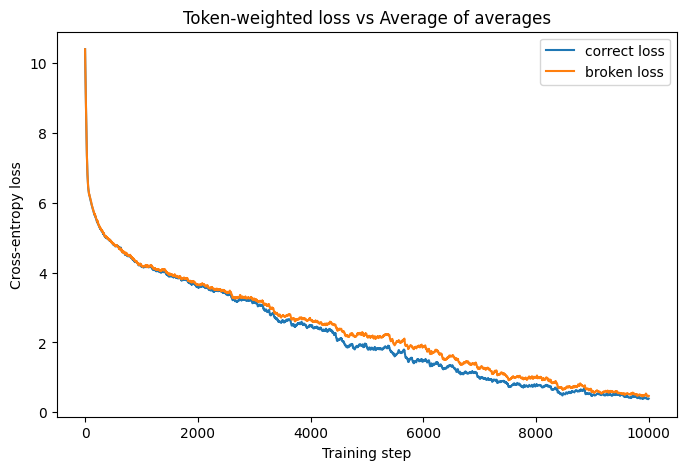

In [30]:
# Plotting loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(correct_losses, label="correct loss")
plt.plot(broken_losses, label="broken loss")

plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Token-weighted loss vs Average of averages")

plt.legend()
plt.show()

## **3.4 Analysis**

The above plot is the loss curve from the training run of two models.
The models start from identical weights, and see identical micro-batches, but use different weighting when accumulating gradients. One uses token-weighted loss (correct loss), whereas the other uses average of averages for gradient accumulation (broken loss)

As seen from the plot, their losses initially track closely, then gradually diverge. After ~2,000 optimizer steps, the token-weighted run has a lower loss on the fixed diagnostic batch than the average-of-averages run.

This continues upto ~9000 optimizer steps, after which the losses start converging.

# **4. Gradient norm analysis**

"Log the grad norm at every step, then find one step where it moved before the loss did."



## **4.1 Model and Training Loop for gradnorm**

In [58]:
# # Grad norm was also saved in the correct 10K model run

# model = model_correct
# grad_norms = correct_grad_norms
# losses = train_losses_correct
# # losses = correct_losses

In [137]:
B = 4   # Batch Size
T = 128 # Seq Length
seed = 42

# Create the model config
config = GPTConfig(
    block_size=T,
    vocab_size=vocab_size,
    n_layer=n_layer,
    n_head=n_head,
    n_embd=n_embd
)

# Create the models
model = GPT(config)
model.to(device)

# Tokenizer
enc = tiktoken.get_encoding("gpt2")

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4
)


### **Training Loop with grad norm**

In [138]:
num_steps = 4000
grad_accum_steps = 8

# For plotting grad norm and loss
grad_norms = []
train_losses = []
val_losses = []


for step in range(num_steps):
    if step % 500 == 0:
        print(f"In step {step}")

    optimizer.zero_grad(set_to_none=True)

    # Returns as many micro-batches as gradient accumulation steps configured
    batches = get_batches(
        data,
        B,
        grad_accum_steps,
        step,
        seed,
    )

    # Count of total tokens across all micro-batches in this accumulation window
    total_tokens = sum(
        batch["num_tokens"]
        for batch in batches
    )

    step_loss = 0.0

    for batch in batches:
        tokens = batch["tokens"]
        n_tokens = batch["num_tokens"]

        loss = compute_loss(model, tokens)

        weight = n_tokens / total_tokens

        # Record the same weighted loss used for gradient accumulation
        step_loss += loss.item() * weight

        # Accumulate gradients
        (loss * weight).backward()

    # Gradient and loss describe the same θ_t
    grad_norm = get_grad_norm(model)

    # Evaluate on fixed diagnostic batch after optimizer update
    with torch.no_grad():
        eval_loss = compute_loss(
            model,
            eval_tokens
        ).item()


    train_losses.append(step_loss)
    val_losses.append(eval_loss)
    grad_norms.append(grad_norm)


    # Update θ_t → θ_{t+1}
    optimizer.step()


In step 0
In step 500
In step 1000
In step 1500
In step 2000
In step 2500
In step 3000
In step 3500


In [139]:
# Use training loss for comparison
losses = train_losses


## **4.2 Plots to inspect gradient norm**




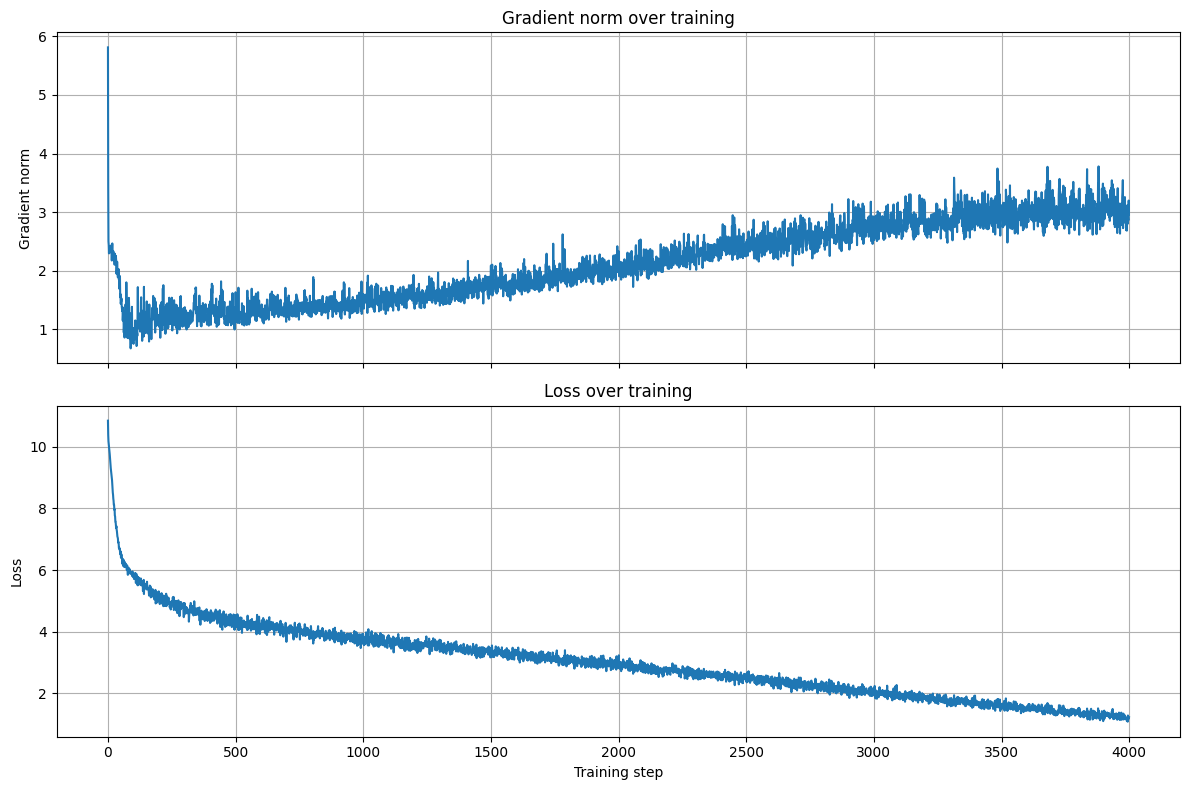

In [140]:
# Noisy graph

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gradient norm
axes[0].plot(grad_norms)
axes[0].set_ylabel("Gradient norm")
axes[0].set_title("Gradient norm over training")
axes[0].grid(True)

# Loss
axes[1].plot(losses)
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss over training")
axes[1].grid(True)

plt.tight_layout()
plt.show()

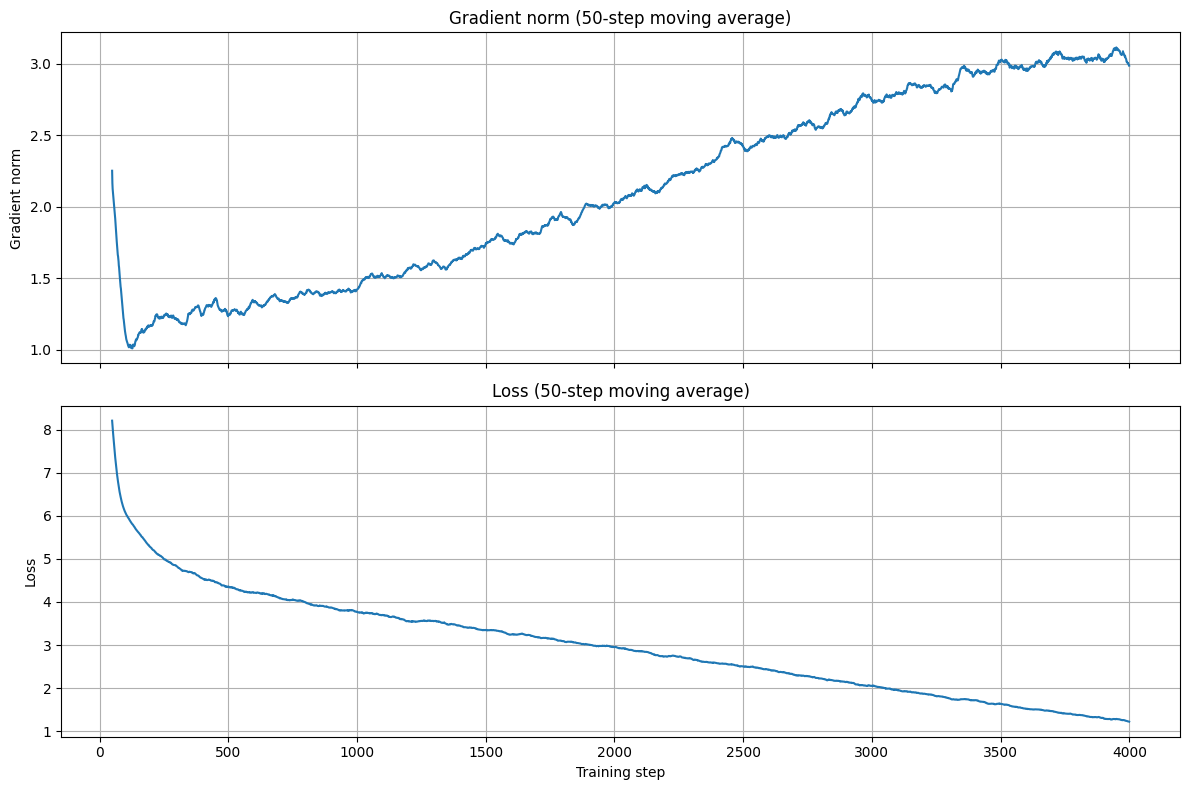

In [141]:
# Adding Rolling mean to smoothen the grad norm plots

import matplotlib.pyplot as plt

grad_norms = np.array(grad_norms)
losses = np.array(losses)

window = 50

grad_smooth = np.convolve(
    grad_norms,
    np.ones(window) / window,
    mode="valid"
)

loss_smooth = np.convolve(
    losses,
    np.ones(window) / window,
    mode="valid"
)

steps_smooth = np.arange(window - 1, len(grad_norms))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(steps_smooth, grad_smooth)
axes[0].set_ylabel("Gradient norm")
axes[0].set_title(f"Gradient norm ({window}-step moving average)")
axes[0].grid(True)

axes[1].plot(steps_smooth, loss_smooth)
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Loss")
axes[1].set_title(f"Loss ({window}-step moving average)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [142]:
candidate = 700 #1650

# Check a small window around the candidate step
for step in range(candidate - 5, candidate + 10):
    grad_delta = grad_norms[step] - grad_norms[step - 1]
    loss_delta = losses[step] - losses[step - 1]
    print(
        f"step {step:4d} | "
        f"grad={grad_norms[step]:.4f} | "
        f"loss={losses[step]:.4f} | "
        f"Δgrad={grad_delta:+.6f} | "
        f"Δloss={loss_delta:+.6f}"
    )


step  695 | grad=1.7082 | loss=4.1601 | Δgrad=+0.486694 | Δloss=+0.132838
step  696 | grad=1.3392 | loss=4.2864 | Δgrad=-0.369054 | Δloss=+0.126248
step  697 | grad=1.3527 | loss=3.9792 | Δgrad=+0.013520 | Δloss=-0.307207
step  698 | grad=1.1287 | loss=3.9756 | Δgrad=-0.224003 | Δloss=-0.003580
step  699 | grad=1.2474 | loss=3.6704 | Δgrad=+0.118665 | Δloss=-0.305217
step  700 | grad=1.2095 | loss=3.9635 | Δgrad=-0.037891 | Δloss=+0.293125
step  701 | grad=1.5331 | loss=4.1207 | Δgrad=+0.323634 | Δloss=+0.157219
step  702 | grad=1.3283 | loss=4.0323 | Δgrad=-0.204785 | Δloss=-0.088441
step  703 | grad=1.4145 | loss=4.0288 | Δgrad=+0.086175 | Δloss=-0.003445
step  704 | grad=1.4118 | loss=4.1371 | Δgrad=-0.002686 | Δloss=+0.108283
step  705 | grad=1.2473 | loss=4.0408 | Δgrad=-0.164487 | Δloss=-0.096259
step  706 | grad=1.2894 | loss=4.0975 | Δgrad=+0.042107 | Δloss=+0.056703
step  707 | grad=1.3223 | loss=4.0852 | Δgrad=+0.032853 | Δloss=-0.012305
step  708 | grad=1.5769 | loss=4.1305 

## **4.3 Identify candidate steps where gradnorm changed**



In [143]:
# import numpy as np


# def find_gradient_candidates(
#     grad_norms,
#     losses,
#     min_step=1000,
#     smooth_window=20,
#     grad_threshold=2.0,
#     loss_threshold=0.002,
#     top_k=20,
# ):

#     """
#     Find training steps where the gradient norm changed substantially
#     while the loss changed very little.

#     Args:
#         grad_norms: gradient norm recorded at every training step.
#         losses: loss recorded at every training step.
#         smooth_window: number of steps to average gradient norm over.
#         grad_threshold: minimum normalized gradient change.
#         loss_threshold: maximum immediate loss change.
#         top_k: maximum number of candidates to return.

#     Returns:
#         List of candidate dictionaries.
#     """


#     grad_norms = np.asarray(grad_norms)
#     losses = np.asarray(losses)

#     # Smooth the entire gradient history first - signal is too noisy
#     kernel = np.ones(smooth_window) / smooth_window

#     grad_smooth = np.convolve(
#         grad_norms,
#         kernel,
#         mode="valid",
#     )

#     # Step corresponding to each smoothed value
#     smooth_steps = np.arange(
#         smooth_window - 1,
#         len(grad_norms)
#     )

#     # Change in smoothed gradient
#     smooth_grad_delta = np.diff(grad_smooth)

#     # Typical magnitude of gradient-norm changes
#     grad_scale = np.std(smooth_grad_delta)

#     if grad_scale == 0:
#         raise ValueError(
#             "Smoothed gradient did not change."
#         )

#     candidates = []

#     for i, d_grad in enumerate(smooth_grad_delta):
#         step = smooth_steps[i + 1]

#         # Ignore early training
#         if step < min_step:
#             continue

#         d_loss = losses[step] - losses[step - 1]
#         grad_score = abs(d_grad) / grad_scale

#         if (
#             grad_score >= grad_threshold
#             and abs(d_loss) <= loss_threshold
#         ):
#             candidates.append({
#                 "step": step,
#                 "grad_smooth": grad_smooth[i + 1],
#                 "grad_smooth_change": d_grad,
#                 "grad_score": grad_score,
#                 "grad_raw": grad_norms[step],
#                 "loss": losses[step],
#                 "loss_change": d_loss,
#             })

#     candidates.sort(
#         key=lambda x: x["grad_score"],
#         reverse=True,
#     )

#     return candidates[:top_k]

# def analyze_gradient_candidates(
#     candidates,
#     grad_norms,
#     losses,
#     lookahead=10,
#     top_k=5,
# ):
#     """
#     Analyze candidate steps for a subsequent loss response.

#     Args:
#         candidates: output from find_gradient_candidates().
#         grad_norms: full gradient norm history.
#         losses: full loss history.
#         lookahead: number of steps to look ahead.
#         top_k: number of final candidates to return.

#     Returns:
#         Candidates ranked by subsequent loss movement.
#     """

#     grad_norms = np.asarray(grad_norms)
#     losses = np.asarray(losses)

#     analyzed = []

#     for candidate in candidates:
#         step = candidate["step"]

#         # Need enough future steps
#         if step + lookahead >= len(losses):
#             continue

#         loss_now = losses[step]
#         loss_future = losses[step + lookahead]
#         future_loss_delta = loss_future - loss_now

#         result = candidate.copy()
#         result["future_loss"] = loss_future
#         result["future_loss_change"] = future_loss_delta
#         result["future_loss_change_abs"] = abs(
#             future_loss_delta
#         )

#         analyzed.append(result)

#     # Rank by magnitude of subsequent loss movement
#     analyzed.sort(
#         key=lambda x: x["future_loss_change_abs"],
#         reverse=True,
#     )

#     return analyzed[:top_k]

In [158]:
import numpy as np


def find_gradient_lead_candidates(
    grad_norms,
    losses,
    min_step=1000,
    grad_smooth_window=20,
    loss_smooth_window=10,
    lookahead=10,
    grad_threshold=1.5,
    immediate_loss_threshold=0.005,
    future_loss_threshold=0.05,
    top_k=10,
):
    """
    Find steps where gradient movement appears to precede
    a subsequent movement in training loss.

    Candidate criteria:
      1. Smoothed gradient changes substantially.
      2. Immediate loss change is relatively small.
      3. Loss changes substantially within `lookahead` steps.

    Parameters
    ----------
    grad_norms : Gradient norm recorded at every training step.
    losses : Training loss recorded at every training step.
    min_step : Ignore candidates before this step.
    grad_smooth_window : Moving-average window for gradient norm.
    loss_smooth_window : Moving-average window for training loss.
    lookahead : Number of steps after candidate to inspect for subsequent loss movement.
    grad_threshold : Number of standard deviations above the typical
        smoothed-gradient change required to consider a candidate.
    immediate_loss_threshold : Maximum allowed absolute raw loss change at the candidate step.
    future_loss_threshold : Minimum absolute smoothed-loss change required
        over the lookahead period.
    top_k : Number of candidates to return.

    Returns
    -------
    candidates : list of dict
        Candidate steps sorted by future loss movement.
    """

    grad_norms = np.asarray(grad_norms, dtype=float)
    losses = np.asarray(losses, dtype=float)

    if len(grad_norms) != len(losses):
        raise ValueError(
            "grad_norms and losses must have the same length."
        )

    if len(grad_norms) < max(
        grad_smooth_window,
        loss_smooth_window,
    ) + lookahead:
        raise ValueError(
            "Not enough steps for the requested smoothing/lookahead."
        )

    # ---------------------------------------------------------
    # 1. Smooth gradient and loss
    # ---------------------------------------------------------

    grad_kernel = np.ones(grad_smooth_window) / grad_smooth_window
    loss_kernel = np.ones(loss_smooth_window) / loss_smooth_window

    grad_smooth = np.convolve(
        grad_norms,
        grad_kernel,
        mode="valid",
    )

    loss_smooth = np.convolve(
        losses,
        loss_kernel,
        mode="valid",
    )

    # Original training-step corresponding to each smoothed value
    grad_steps = np.arange(
        grad_smooth_window - 1,
        len(grad_norms),
    )

    loss_steps = np.arange(
        loss_smooth_window - 1,
        len(losses),
    )

    # ---------------------------------------------------------
    # 2. Change in smoothed gradient
    # ---------------------------------------------------------

    d_grad = np.diff(grad_smooth)

    # Standard deviation of normal gradient movement.
    grad_scale = np.std(d_grad)

    if grad_scale == 0:
        raise ValueError(
            "Smoothed gradient does not change."
        )

    # ---------------------------------------------------------
    # 3. Find candidate gradient movements
    # ---------------------------------------------------------

    candidates = []

    for i, grad_change in enumerate(d_grad):

        # The diff between grad_smooth[i] and grad_smooth[i+1]
        # corresponds to this original training step.
        step = grad_steps[i + 1]

        if step < min_step:
            continue

        if step + lookahead >= len(losses):
            continue

        # How unusual is this gradient movement?
        grad_score = abs(grad_change) / grad_scale

        if grad_score < grad_threshold:
            continue

        # -----------------------------------------------------
        # 4. Immediate loss change
        # -----------------------------------------------------

        immediate_loss_change = (
            losses[step] - losses[step - 1]
        )

        if abs(immediate_loss_change) > immediate_loss_threshold:
            continue

        # -----------------------------------------------------
        # 5. Future smoothed loss change
        # -----------------------------------------------------

        # Find smoothed-loss index corresponding to `step`
        loss_idx = step - (loss_smooth_window - 1)

        future_step = step + lookahead

        future_loss_idx = (
            future_step
            - (loss_smooth_window - 1)
        )

        if loss_idx < 0 or future_loss_idx >= len(loss_smooth):
            continue

        current_smooth_loss = loss_smooth[loss_idx]

        future_smooth_loss = loss_smooth[future_loss_idx]

        future_loss_change = (
            future_smooth_loss
            - current_smooth_loss
        )

        if abs(future_loss_change) < future_loss_threshold:
            continue

        # -----------------------------------------------------
        # 6. Save candidate
        # -----------------------------------------------------

        candidates.append({
            "step": int(step),
            "grad_raw": float(grad_norms[step]),
            "grad_smooth": float(grad_smooth[i + 1]),
            "grad_change": float(grad_change),
            "grad_score": float(grad_score),
            "loss_raw": float(losses[step]),
            "loss_smooth": float(current_smooth_loss),
            "immediate_loss_change": float(immediate_loss_change),
            "future_loss": float(future_smooth_loss),
            "future_loss_change": float(future_loss_change),
        })

    # ---------------------------------------------------------
    # 7. Rank candidates
    # ---------------------------------------------------------

    candidates.sort(
        key=lambda x: abs(x["future_loss_change"]),
        reverse=True,
    )

    return candidates[:top_k]

In [163]:

# # First find the training window where grad norm changed, then inspect it further to identify areas where loss changed after grad-norm
# # candidates = find_gradient_candidates(
# #     grad_norms,
# #     losses,
# #     min_step=1000,
# #     smooth_window=20,
# #     grad_threshold=2.0,
# #     loss_threshold=0.002,
# #     top_k=20,
# # )

# # final_candidates = analyze_gradient_candidates(
# #     candidates,
# #     grad_norms,
# #     losses,
# #     lookahead=5,
# #     top_k=10,
# # )


candidates = find_gradient_lead_candidates(
    grad_norms,
    train_losses,
    min_step=1000,
    grad_smooth_window=20,
    loss_smooth_window=10,
    lookahead=10,
    grad_threshold=1,
    immediate_loss_threshold=0.005,
    future_loss_threshold=0.05,
    top_k=10,
)

print(f"Top 10 candidates for inspection")
# for c in final_candidates:
    # print(
    #     f"step {c['step']:4d} | "
    #     f"grad={c['grad_raw']:.4f} | "
    #     f"loss={c['loss']:.4f} | "
    #     f"Δgrad={c['grad_smooth_change']:+.4f} | "
    #     f"Δloss={c['loss_change']:+.4f} | "
    #     f"10-step Δloss={c['future_loss_change']:+.4f}"
    # )

for c in candidates:
    print(
        f"step {c['step']:4d} | "
        f"grad={c['grad_raw']:.4f} | "
        f"grad Δ={c['grad_change']:+.4f} | "
        f"grad score={c['grad_score']:.2f} | "
        f"loss={c['loss_raw']:.4f} | "
        f"immediate Δloss={c['immediate_loss_change']:+.4f} | "
        f"future Δloss={c['future_loss_change']:+.4f}"
    )

Top 10 candidates for inspection
step 1356 | grad=1.8404 | grad Δ=+0.0147 | grad score=1.24 | loss=3.4493 | immediate Δloss=+0.0003 | future Δloss=+0.0885
step 3008 | grad=2.9049 | grad Δ=-0.0137 | grad score=1.16 | loss=2.0263 | immediate Δloss=+0.0019 | future Δloss=-0.0792
step 1288 | grad=1.5741 | grad Δ=-0.0149 | grad score=1.26 | loss=3.3943 | immediate Δloss=+0.0011 | future Δloss=+0.0658
step 3075 | grad=2.8474 | grad Δ=-0.0140 | grad score=1.19 | loss=1.8069 | immediate Δloss=-0.0043 | future Δloss=+0.0596
step 1904 | grad=1.9003 | grad Δ=-0.0127 | grad score=1.07 | loss=2.8508 | immediate Δloss=+0.0022 | future Δloss=+0.0595
step 2869 | grad=2.9437 | grad Δ=+0.0232 | grad score=1.97 | loss=2.1506 | immediate Δloss=-0.0000 | future Δloss=-0.0527


### Helper functions for plots

In [178]:
import numpy as np
import matplotlib.pyplot as plt


def plot_candidate(
    step,
    grad_norms,
    losses,
    radius=25,
    smooth_window=20,
):
    """
    Plot gradient norm and loss around a candidate step.

    Args:
        step: candidate training step
        grad_norms: recorded raw gradient norms
        losses: recorded losses
        radius: number of steps shown before/after candidate
        smooth_window: window for smoothed gradient
    """

    grad_norms = np.asarray(grad_norms)
    losses = np.asarray(losses)

    start = max(0, step - radius)
    end = min(len(grad_norms), step + radius + 1 + 10)

    steps = np.arange(start, end)

    # Smooth the entire gradient history first
    kernel = np.ones(smooth_window) / smooth_window

    grad_smooth = np.convolve(
        grad_norms,
        kernel,
        mode="valid",
    )

    loss_smooth = np.convolve(
        losses,
        kernel,
        mode="valid",
    )

    # Step corresponding to each smoothed value
    smooth_steps = np.arange(
        smooth_window - 1,
        len(grad_norms)
    )

    # Only take the portion corresponding to our plot window
    mask = (
        (smooth_steps >= start) &
        (smooth_steps < end)
    )

    local_smooth_steps = smooth_steps[mask]
    local_grad_smooth = grad_smooth[mask]
    local_loss_smooth = loss_smooth[mask]

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10, 7),
        sharex=True,
    )

    # -------------------------
    # Gradient
    # -------------------------
    axes[0].plot(
        steps,
        grad_norms[start:end],
        label="raw gradient norm",
        alpha=0.4,
    )

    axes[0].plot(
        local_smooth_steps,
        local_grad_smooth,
        label=f"{smooth_window}-step moving average",
    )

    axes[0].axvline(
        step,
        linestyle="--",
        label=f"candidate step {step}",
    )

    axes[0].set_ylabel("Gradient norm")
    axes[0].set_title(
        f"Gradient around step {step}"
    )
    axes[0].legend()
    axes[0].grid(True)

    # -------------------------
    # Loss
    # -------------------------
    axes[1].plot(
        steps,
        losses[start:end],
        label="raw loss",
        alpha=0.4,
    )

    # Comment this out to hide the smoothened loss graph
    axes[1].plot(
        local_smooth_steps,
        local_loss_smooth,
        label=f"{smooth_window}-step moving average",
    )


    axes[1].axvline(
        step,
        linestyle="--",
        label=f"candidate step {step}",
    )

    axes[1].set_xlabel("Training step")
    axes[1].set_ylabel("Loss")
    axes[1].set_title(
        f"Loss around step {step}"
    )
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## **4.4 Plot some steps where grad-norm changed before loss**

Excluded the initial 1,000 optimization steps from candidate selection because they contained a large change in both gradient norm and loss, making it hard to find any correlation. In later training steps, the loss and gradient signals had a more gradual change

**Gradnorm / Loss plots**

The gradient norm is
$∥g_{t}∥  =  ∥∇_{θ}L(θ_{t})∥$   
It tells us the magnitude of the gradient, not its direction.  

Things to note:
- A larger gradient norm does not necessarily mean loss will increase or decrease
- A smaller gradient norm does not necessarily mean loss will move in a particular direction
- What matters for the loss change is the direction of the update, optimizer state, curvature, and the data being evaluated



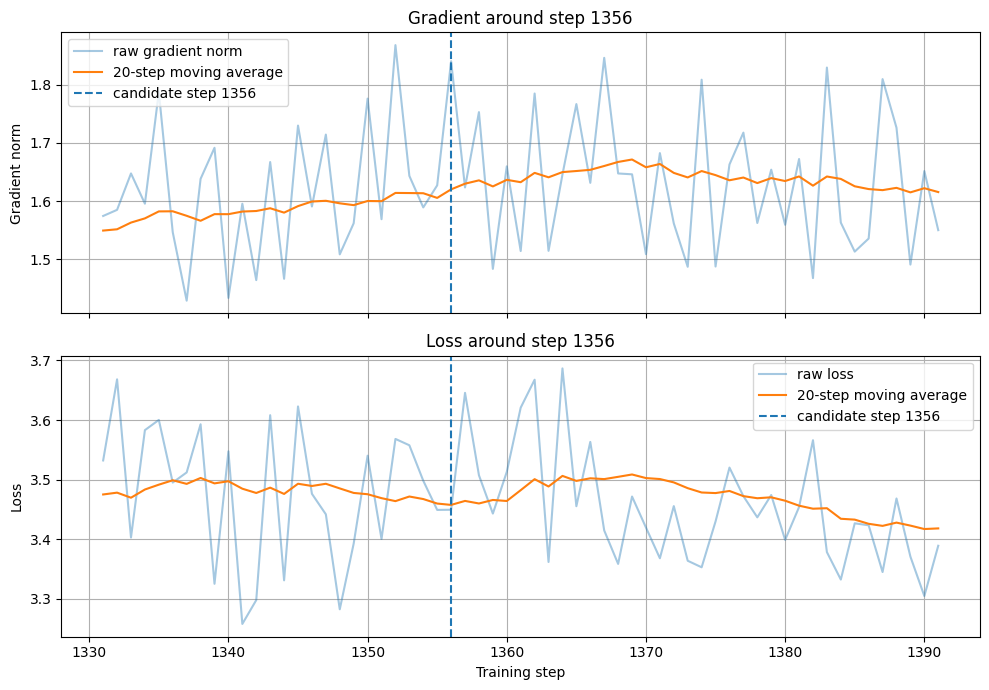

In [179]:
# Grad norm plot
plot_candidate(
    step=1356,
    grad_norms=grad_norms,
    losses=losses,
    radius=25,
)

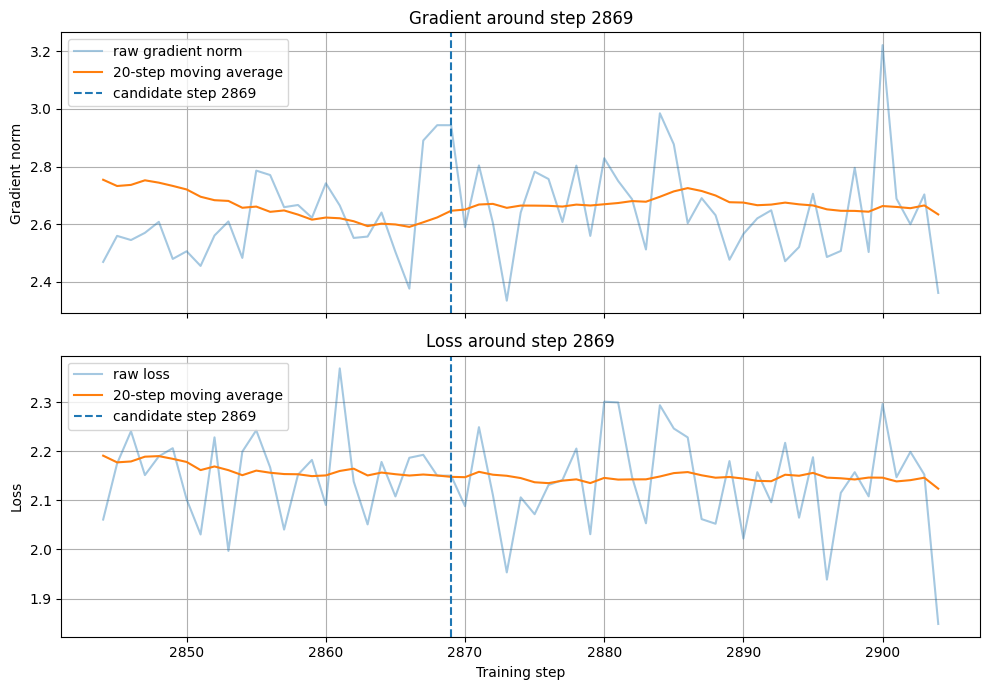

In [180]:
# plot_candidate(
    step=2869,
    grad_norms=grad_norms,
    losses=losses,
    radius=25,
)

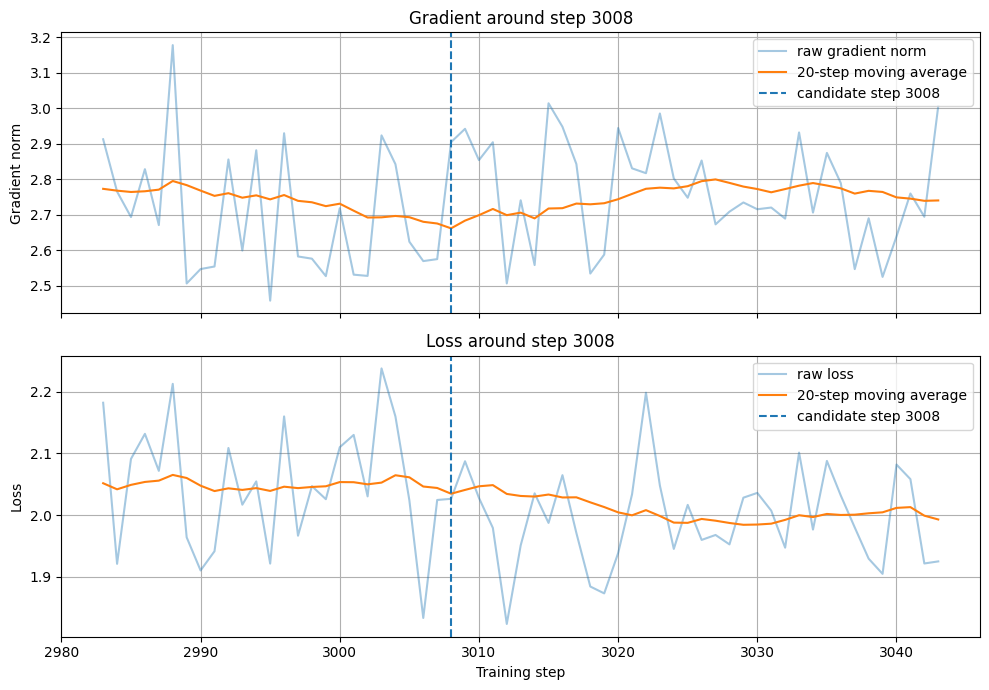

In [181]:
# plot_candidate(
    step=3008,
    grad_norms=grad_norms,
    losses=losses,
    radius=25,
)

# **5. Compute MFU (Model FLOPS Utilization)**

MFU = Floating point operations (FLOPs) that the training actually performs per second ÷ the GPU's theoretical peak FLOPs per second.

There are three things we need to do:
1. Estimate FLOPs per training token for the model
2. Measure tokens/second during actual training
3. Know the GPU's theoretical peak FLOPs for the precision we are using

## **5.1 Calculate FLOPs per token**

For a GPT-style transformer, a common approximation is:

$$ \text{FLOPs/token} \approx 6N $$

where \(N\) is the number of non-embedding model parameters.  
   
The 6N comes approximately from:

forward pass: ~2 FLOPs per parameter  
backward pass: ~4 FLOPs per parameter  

so:  

$$ 2N + 4N \approx 6N $$

There is also an additional FLOP contribution from self-attention that depends on sequence length.

Karpathy's nanoGPT MFU calculation uses approximately:

$$ \text{FLOPs/token} = 6N + 12Lh d_h T $$

where:

**N** = non-embedding parameters  
**L** = number of transformer layers  
**h** = number of attention heads  
**d_h** = head dimension  
**T** = sequence length  

Since:
$ h d_h = C $

this can also be written as:  $ \text{6N+12LCT} $

In [101]:
import torch

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)
print("PyTorch:", torch.__version__)
print()

# Model param count
n_params = sum(
    p.numel()
    for p in model.parameters()
)

embedding_params = (
    model.transformer.wte.weight.numel()
    + model.transformer.wpe.weight.numel()
)

n_non_embedding = n_params - embedding_params

print(f"Total parameters:       {n_params:,}")
print(f"Embedding parameters:   {embedding_params:,}")
print(f"Non-embedding params:   {n_non_embedding:,}")

GPU: Tesla T4
CUDA: 12.8
PyTorch: 2.11.0+cu128

Total parameters:       16,058,112
Embedding parameters:   12,898,560
Non-embedding params:   3,159,552


In [102]:
L = config.n_layer
C = config.n_embd
H = config.n_head
D = C // H

T = 128

flops_per_token = (
    6 * n_non_embedding
    + 12 * L * H * D * T
)

print(f"FLOPs/token: {flops_per_token:,.0f}")

FLOPs/token: 20,530,176


## **5.2 Measure tokens/sec during actual training**

In [103]:
def benchmark_training(
    model,
    optimizer,
    data,
    B=4,
    grad_accum_steps=4,
    num_warmup=20,
    num_steps=100,
    seed=42,
):

    model.train()

    # -------------------------
    # Warmup
    # -------------------------
    for step in range(num_warmup):

        optimizer.zero_grad(set_to_none=True)

        batches = get_batches(
            data,
            B=B,
            grad_accum_steps=grad_accum_steps,
            step=step,
            seed=seed,
        )

        total_tokens = sum(
            batch["num_tokens"]
            for batch in batches
        )

        for batch in batches:
            tokens = batch["tokens"]
            n_tokens = batch["num_tokens"]

            loss = compute_loss(model, tokens)

            weight = n_tokens / total_tokens
            (loss * weight).backward()

        optimizer.step()

    # Make sure warmup GPU work is finished
    torch.cuda.synchronize()

    # -------------------------
    # Timed region
    # -------------------------
    total_input_tokens = 0

    start = time.perf_counter()

    for step in range(num_steps):

        optimizer.zero_grad(set_to_none=True)

        batches = get_batches(
            data,
            B=B,
            grad_accum_steps=grad_accum_steps,
            step=num_warmup + step,
            seed=seed,
        )

        total_tokens = sum(
            batch["num_tokens"]
            for batch in batches
        )

        # Number of tokens actually processed by model
        total_input_tokens += sum(
            batch["tokens"].numel()
            for batch in batches
        )

        for batch in batches:
            tokens = batch["tokens"]
            n_tokens = batch["num_tokens"]

            loss = compute_loss(model, tokens)

            weight = n_tokens / total_tokens
            (loss * weight).backward()

        optimizer.step()

    # We need to synchronize CUDA before and after timing
    torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    # Calculated for global batch, not micro-batch
    tokens_per_sec = total_input_tokens / elapsed

    return {
        "elapsed": elapsed,
        "tokens": total_input_tokens,
        "tokens_per_sec": tokens_per_sec,
    }

In [104]:
result = benchmark_training(
    model,
    optimizer,
    data,
    B=4,
    grad_accum_steps=4,
)

print(result)


{'elapsed': 7.370050427000024, 'tokens': 129092, 'tokens_per_sec': 17515.755323338657}


In [105]:
tokens_per_sec = result["tokens_per_sec"]
achieved_flops = flops_per_token * tokens_per_sec
achieved_tflops = achieved_flops * 1e-12 # multiply by 10^-12

print(f"FLOPs/token: {flops_per_token:,.0f}")
print(f"Tokens/sec:  {tokens_per_sec:,.0f}")
print(f"Achieved FLOPs: {achieved_flops:,.0f}")
print(f"Achieved TFLOPs: {achieved_tflops}")


FLOPs/token: 20,530,176
Tokens/sec:  17,516
Achieved FLOPs: 359,601,539,561
Achieved TFLOPs: 0.35960153956107954


## **5.3 Find GPU's peak FLOPS**

NVIDIA specifies the Tesla T4 at:

8.1 TFLOPS FP32  
65 TFLOPS FP16 Tensor Core performance


In [106]:
print("GPU:", torch.cuda.get_device_name(0))
print("Model dtype:", next(model.parameters()).dtype)
print("Autocast dtype:", torch.get_autocast_gpu_dtype())
print("Autocast enabled:", torch.is_autocast_enabled())
print("TF32 enabled:", torch.backends.cuda.matmul.allow_tf32)

GPU: Tesla T4
Model dtype: torch.float32
Autocast dtype: torch.float16
Autocast enabled: False
TF32 enabled: False


/tmp/ipykernel_2000/1687258578.py:3: DeprecationWarning: torch.get_autocast_gpu_dtype() is deprecated. Please use torch.get_autocast_dtype('cuda') instead. (Triggered internally at /pytorch/torch/csrc/autograd/init.cpp:881.)
  print("Autocast dtype:", torch.get_autocast_gpu_dtype())


In [107]:
# Since we have been using FP32 for training,

peak_flops = 8.1
mfu = achieved_tflops / peak_flops
print(f"MFU: {mfu:.2%}")

MFU: 4.44%


## **5.4 MFU Analysis**


| Parameter                  |             Result |
| -------------------------  | -----------------: |
| GPU                        |           Tesla T4 |
| Model weights              | FP32               |
| Autocast configured dtype  | FP16               |
| Autocast actually active   | No                 |
| Training arithmetic        | FP32               |
| T4 FP32 peak flops         | 8.1 TFLOPS         |
| Training throughput        |    21,260 tokens/s |
| FLOPs/token                |         20,530,176 |
| Measured FLOPs/s           |    436,476,011,710 |
| Measured TFLOPs/s          | **0.436 TFLOPs/s** |      


$ P_{peak}​ =8.1 $ TFLOP/s   

Therefore:

$ MFU = 8.1 / 0.4365 $   
$ \quad \quad \quad \approx 0.0539 $

$$ MFU \approx 5.4 \%  $$


#### Reasons for low MFU

1. **Very small model  **
A tiny transformer simply doesn't provide enough work to keep all the Tensor Cores busy.

2. **Small batch/micro-batch size**  
Currently, B = 4 with grad_accum_steps = 4.
Not designed to maximize MFU

3. **Variable sequence lengths**  
Our experiment deliberately generates   
T = 32 ... 128   
    This is good for demonstrating the gradient-accumulation bug, but again not ideal for GPU efficiency.

4. **CPU → GPU transfers**   
The get_batch() function does:  
    ```return x.to(device)```  
    So for every micro-batch, we repeatedly do:   
    ```CPU tensor -> GPU transfer -> forward -> backward```   
    This can contribute significantly to the gap, particularly with a small model.

5. **Python overhead**    
For a tiny model, Python and framework overhead can become a surprisingly significant fraction of total runtime.



# **6. Number formats**

Take the number 0.1 and write out by hand what it looks like in fp32, bf16 and fp8 E4M3, showing the bits. Then say which one you would train in, and why.


## **6.1 Binary representation of 0.1**

Decimal numbers like:  $ 0.123 $
mean:

$ 0×10^{−1} +1×10^{−2} +2×10^{−3}  $


Binary works exactly the same way, except the powers are powers of 2.

**Binary to Decimal**

For example:

0.101₂ means

$ 1×2^{-1} + 0×2^{-2} + 1×2^{-3} $  
which is  
$ \frac{1}{2} + 0 + \frac{1}{8}  $
$ = 0.5 + 0.125 $   
$ = 0.625 $


So ```0.101₂ = 0.625₁₀```


**Decimal to Binary**   

We want to find:

$$ 0.1_{10} = ?_{2} $$

To convert decimal to binary, keep multiplying the fraction by 2. The integer part you get becomes the next binary digit. In table format:  


| Step |      Fraction × 2 | Binary digit | New fraction |
| ---: | ----------------: | :----------: | -----------: |
|    1 | 0.1 × 2 = **0.2** |       0      |          0.2 |
|    2 | 0.2 × 2 = **0.4** |       0      |          0.4 |
|    3 | 0.4 × 2 = **0.8** |       0      |          0.8 |
|    4 | 0.8 × 2 = **1.6** |       1      |          0.6 |
|    5 | 0.6 × 2 = **1.2** |       1      |          0.2 |
|    6 | 0.2 × 2 = **0.4** |       0      |          0.4 |
|    7 | 0.4 × 2 = **0.8** |       0      |          0.8 |
|    8 | 0.8 × 2 = **1.6** |       1      |          0.6 |
|    9 | 0.6 × 2 = **1.2** |       1      |          0.2 |

Collect all the binary digits. We get  
0 0 0 1 1 0 0 1 1 0 0 1 1 ...   

Therefore:
$$ 0.1_{10} = 000110011001100110011..._{2} $$

$$ 0.1_{10} = 1.10011001100110011..._{2} × 2^{−4} $$

**Why doesn't it stop**    
Some decimal fractions have finite binary representations, but 0.1 is different.   
To represent a number exactly in binary, it has to be expressible using sums of:   

$ \frac{1}{2}, \frac{1}{4}, \frac{1}{8}, \frac{1}{16}, ...  $

But $ 0.1 = \frac{1}{10} $, which contains a factor of 5.     
Binary only has factors of 2 in its denominator, so 1/10 cannot be represented exactly as a finite sum of powers of 1/2.    
So we get:   0.000110011001100110011...   which never ends   
This is similar to $ \frac{1}{3} = 0.333333333...  $



## **6.2 FP32, BF16 and FP8 E4M3 Formats**

A number is represented by three parts:
1. Sign: Positive or negative
2. Exponent: How large the number is
3. Mantissa: The actual value

Some formats also have a Bias field.  
The bias is a trick used to store both positive and negative exponents using an unsigned binary field.  
Instead of storing `E`, we store `Estored​ = E + bias`  


| Format    | Bits | Exponent | Mantissa | Bias | Smallest  Value |
| --------- | ---- | -------- | -------- | ---- | --------------- |
| fp32      | 32   |     8    |    23    | 127  | $1.18×10^{−38}$ |
| fp16      | 16   |     5    |    10    | 15   | $6.1×10^{−5} $  |
| bf16      | 16   |     8    |     7    | 127  | $1.18×10^{−38}$ |
| fp8 E4M3  |  8   |     4    |     3    | 7    | $1.56×10^{−2}$  |
| fp8 E5M2  |  8   |     5    |     2    | 15   | $6.10×10^{−5}$  |
| fp4 E2M1  |  4   |     2    |     1    |  1   | 1.0             |





## **6.3 Write 0.1 in different formats**

0.1 in binary can be written as:

$ 0.1 = 1.10011001100110011…2​×2^{-4} $

### **FP32**
FP32 has 8 bits for exponent, 23 bits for mantissa, and a `Bias` of 127 bits.  

So for 0.1:   
- Sign = 0  
- Actual exponent = -4  
- Stored exponent = -4 + 127 = 123   

123 in binary = 01111011   
Mantissa comes from the 23 bits after the leading 1:   `10011001100110011001100...`     

Take 23 bits of the Mantissa and apply rounding.  So the FP32 representation is:  
```text
Sign       Exponent          Mantissa
 ↓            ↓                 ↓
[0]       [01111011] [10011001100110011001101]
```   

which gives   `00111101110011001100110011001101`    

### **BF16**  

Bf16 has a `Bias` field of 127 bits.  
It has the same 8-bit exponent as FP32, but only 7 Mantissa bits.
The exponent therefore stays exactly the same, and the mantissa is truncated:

```text
Sign       Exponent          Mantissa
 ↓            ↓                 ↓
[0]       [01111011]        [1001100]
```   
which gives `0011110111001100`

BF16 sacrifices precision, not exponent range.  It can still represent very large and very small values similarly to FP32, even though it has much less precision.

### **FP8 E4M3**
The usual E4M3 format uses an exponent bias of 7 bits. It uses 4 bits for exponent, and 3 bits for Mantissa

So for 0.1:   
- Sign = 0  
- Actual exponent = -4  
- Stored exponent = -4 + 7 = 3   

3 in binary = 0011  
Mantissa comes from the 3 bits after the leading 1:  `100`

0.1 cannot be represented exactly, and with only 3 fraction bits we need to round.   
The next bit after the three mantissa bits is 1, so the mantissa rounds upward:   
`100 → 101`  

So we represent it as:   
```text
Sign       Exponent          Mantissa
 ↓            ↓                 ↓
[0]         [0011]            [101]
```   
which gives `00011101`   


### **Summary**  

0.1 is represented as:   

| Format   | Bits                                 | Approx. value represented | Precision |
| -------- | ------------------------------------ | ------------------------: | --------- |
| FP32     | `0 01111011 10011001100110011001101` |              0.1000000015 | High      |
| BF16     | `0 01111011 1001100`                 |             0.10009765625 | Medium    |
| FP8 E4M3 | `0 0011 101`                         |                 0.1015625 | Low       |


## **6.4 Format to train on**

FP32 has the highest precision and a large exponent range. It can handle very small gradient values. However it is expensive in memory and compute, and this can quickly add up while training.

BF16 has the same range as FP32, but it has only 7 mantissa bits, giving it a lower precision compared to FP32. It has lower memory and compute cost.

FP8 E4M3 has only 3 mantissa bits, so it is a much coarser representation. It has very low memory and compute, making it more efficient. However training becomes more sensitive to scaling and numerical errors.


Overall, BF16 provides much of FP32's dynamic range while using half the storage, making it a good balance between numerical stability, memory usage, and computational efficiency.
